1.Data Creation



In [ ]:
import pandas as pd
import numpy as np
np.random.seed(42)
n_records = 1500
applicant_ids = [f"LP{i:04d}" for i in range(1, n_records + 1)]
gender = np.random.choice(['Male', 'Female'], size=n_records, p=[0.60, 0.40])
age = np.random.randint(21, 66, size=n_records)
employment_status = np.random.choice(['Employed', 'Self-Employed', 'Unemployed'], size=n_records, p=[0.70, 0.20, 0.10])
monthly_income = np.zeros(n_records)
for i in range(n_records):
    if employment_status[i] == 'Employed':
        monthly_income[i] = int(np.random.lognormal(mean=8.5, sigma=0.4))
    elif employment_status[i] == 'Self-Employed':
        monthly_income[i] = int(np.random.lognormal(mean=8.8, sigma=0.5))
    else:
        monthly_income[i] = int(np.random.uniform(500, 1500))
credit_score = np.random.randint(550, 850, size=n_records)
unemployed_idx = np.where(employment_status == 'Unemployed')[0]
credit_score[unemployed_idx] = np.clip(credit_score[unemployed_idx] - np.random.randint(50, 150, size=len(unemployed_idx)), 300, 850)
existing_loans = np.random.choice([0, 1, 2, 3, 4], size=n_records, p=[0.4, 0.3, 0.2, 0.07, 0.03])
loan_amount = np.zeros(n_records)
for i in range(n_records):
    base_loan = monthly_income[i] * np.random.uniform(15, 45)
    loan_amount[i] = int(np.clip(base_loan, 10000, 500000))
loan_term = np.random.choice([120, 180, 240, 360], size=n_records, p=[0.1, 0.15, 0.15, 0.6])
property_area = np.random.choice(['Urban', 'Semi-Urban', 'Rural'], size=n_records, p=[0.35, 0.40, 0.25])
loan_approved = np.zeros(n_records, dtype=int)
for i in range(n_records):
    prob = 0.5
    if credit_score[i] >= 750: prob += 0.4
    elif credit_score[i] >= 680: prob += 0.2
    elif credit_score[i] < 600: prob -= 0.4
    monthly_payment_est = loan_amount[i] / loan_term[i]
    if monthly_income[i] > 0:
        dti = monthly_payment_est / monthly_income[i]
        if dti > 0.4: prob -= 0.3
        elif dti < 0.2: prob += 0.1
    if employment_status[i] == 'Unemployed': prob -= 0.5
    if existing_loans[i] > 2: prob -= 0.2
    prob = np.clip(prob, 0.02, 0.98)
    loan_approved[i] = np.random.choice([1, 0], p=[prob, 1-prob])
df = pd.DataFrame({
    'ApplicantID': applicant_ids,
    'Gender': gender,
    'Age': age,
    'MonthlyIncome': monthly_income.astype(int),
    'LoanAmount': loan_amount.astype(int),
    'CreditScore': credit_score,
    'EmploymentStatus': employment_status,
    'ExistingLoans': existing_loans,
    'LoanTerm': loan_term,
    'PropertyArea': property_area,
    'LoanApproved': loan_approved
})
df.to_csv('loan_approval_dataset.csv', index=False)
print("Dataset successfully created and exported to 'loan_approval_dataset.csv'!")


Dataset successfully created and exported to 'loan_approval_dataset.csv'!


2.Data Preprocessing

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [3]:
df = pd.read_csv('loan_approval_dataset.csv')

df.head()

,ApplicantID,Gender,Age,MonthlyIncome,LoanAmount,CreditScore,EmploymentStatus,ExistingLoans,LoanTerm,PropertyArea,LoanApproved
0,LP0001,Male,22,10406,192629,640,Self-Employed,3,180,Semi-Urban,1
1,LP0002,Female,26,824,16931,541,Unemployed,3,360,Semi-Urban,0
2,LP0003,Female,48,5886,108347,612,Employed,1,360,Urban,0
3,LP0004,Male,49,1176,29689,514,Unemployed,0,120,Semi-Urban,0
4,LP0005,Male,46,9574,420668,759,Employed,3,360,Rural,0


In [4]:
df.isnull().sum()

,0
ApplicantID,0
Gender,0
Age,0
MonthlyIncome,0
LoanAmount,0
CreditScore,0
EmploymentStatus,0
ExistingLoans,0
LoanTerm,0
PropertyArea,0


In [5]:
df.drop_duplicates(inplace=True)

In [6]:
encoder = LabelEncoder()

df['Gender'] = encoder.fit_transform(df['Gender'])
df['EmploymentStatus'] = encoder.fit_transform(df['EmploymentStatus'])
df['PropertyArea'] = encoder.fit_transform(df['PropertyArea'])

In [7]:
df = df.drop('ApplicantID', axis=1)

In [8]:
scaler = StandardScaler()

scale_cols = ['Age', 'MonthlyIncome', 'LoanAmount', 'CreditScore', 'ExistingLoans', 'LoanTerm']

df[scale_cols] = scaler.fit_transform(df[scale_cols])

3.Exploratory Data Analysis (EDA)

In [9]:
df['LoanApproved'].value_counts()

,count
LoanApproved,
1,959
0,541


In [10]:
df.groupby('LoanApproved')['MonthlyIncome'].mean()

,MonthlyIncome
LoanApproved,
0,-0.235676
1,0.132952


In [11]:
df.groupby('LoanApproved')['CreditScore'].mean()

,CreditScore
LoanApproved,
0,-0.755420
1,0.426154


In [12]:
df['EmploymentStatus'].value_counts()

,count
EmploymentStatus,
0,1054
1,305
2,141


In [13]:
df.corr()

,Gender,Age,MonthlyIncome,LoanAmount,CreditScore,EmploymentStatus,ExistingLoans,LoanTerm,PropertyArea,LoanApproved
Gender,1.000000,-0.057043,-0.040801,-0.026574,0.002252,-0.016853,0.015712,-0.020195,-0.029511,0.002574
Age,-0.057043,1.000000,0.000273,-0.033518,0.040966,0.011568,0.016477,-0.030098,0.019599,0.014483
MonthlyIncome,-0.040801,0.000273,1.000000,0.864388,0.190455,-0.187047,0.003549,-0.035685,-0.006115,0.177013
LoanAmount,-0.026574,-0.033518,0.864388,1.000000,0.181281,-0.185737,0.018481,-0.020727,-0.012740,0.164805
CreditScore,0.002252,0.040966,0.190455,0.181281,1.000000,-0.271526,0.002844,0.007031,0.015209,0.567385
EmploymentStatus,-0.016853,0.011568,-0.187047,-0.185737,-0.271526,1.000000,0.028735,0.017271,-0.045509,-0.279201
ExistingLoans,0.015712,0.016477,0.003549,0.018481,0.002844,0.028735,1.000000,0.015717,-0.006588,-0.073971
LoanTerm,-0.020195,-0.030098,-0.035685,-0.020727,0.007031,0.017271,0.015717,1.000000,0.014830,0.019933
PropertyArea,-0.029511,0.019599,-0.006115,-0.012740,0.015209,-0.045509,-0.006588,0.014830,1.000000,0.015961
LoanApproved,0.002574,0.014483,0.177013,0.164805,0.567385,-0.279201,-0.073971,0.019933,0.015961,1.000000


4.Visualization

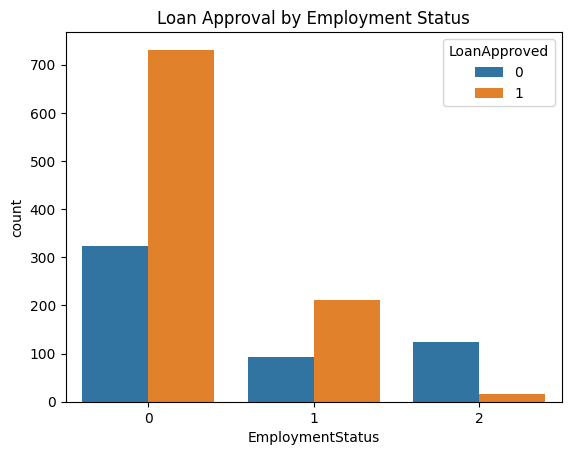

In [14]:
sns.countplot(x='EmploymentStatus', hue='LoanApproved', data=df)

plt.title('Loan Approval by Employment Status')

plt.show()

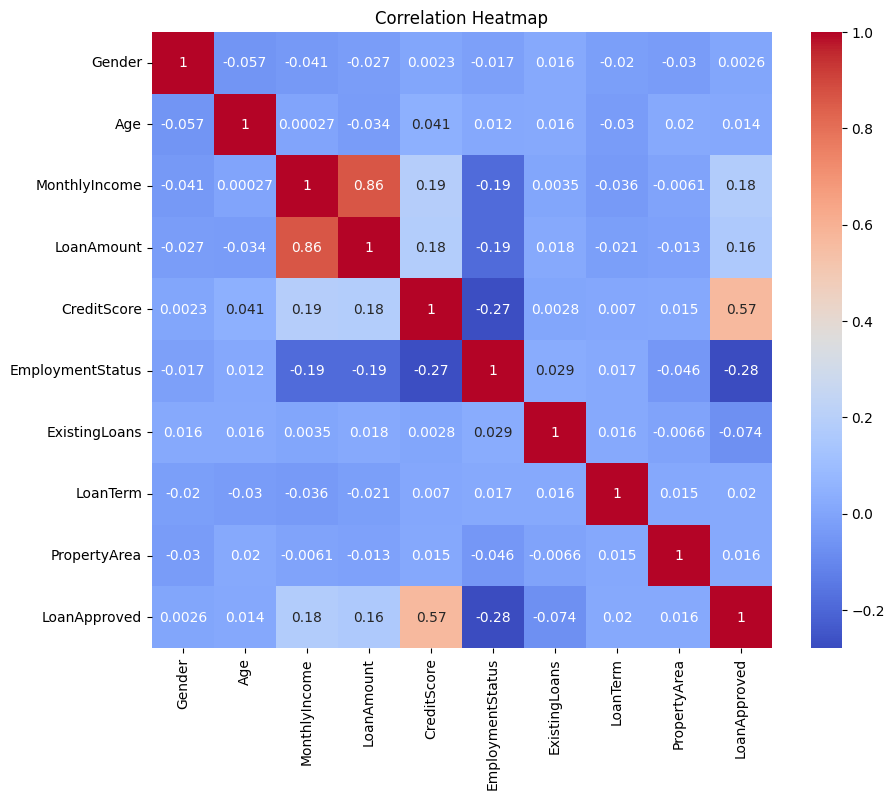

In [15]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()

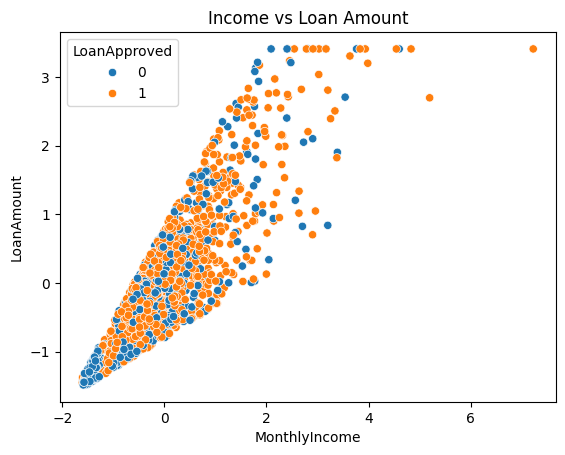

In [16]:
sns.scatterplot(x='MonthlyIncome', y='LoanAmount', hue='LoanApproved', data=df)

plt.title('Income vs Loan Amount')

plt.show()

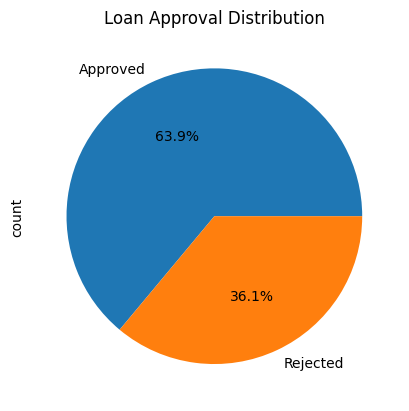

In [17]:
df['LoanApproved'].value_counts().plot.pie(
    autopct='%1.1f%%',
    labels=['Approved', 'Rejected']
)

plt.title('Loan Approval Distribution')

plt.show()

5.Machine Learning Model

In [18]:
X = df.drop('LoanApproved', axis=1)

y = df['LoanApproved']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [21]:
dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [22]:
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [23]:
print("Logistic Regression")

print("Accuracy:", accuracy_score(y_test, lr_pred))

print("Precision:", precision_score(y_test, lr_pred))

print("Recall:", recall_score(y_test, lr_pred))

print("F1 Score:", f1_score(y_test, lr_pred))

print(confusion_matrix(y_test, lr_pred))

Logistic Regression
Accuracy: 0.76
Precision: 0.7358490566037735
Recall: 0.9069767441860465
F1 Score: 0.8125
[[ 72  56]
 [ 16 156]]


In [24]:
print("Decision Tree")

print("Accuracy:", accuracy_score(y_test, dt_pred))

print("Precision:", precision_score(y_test, dt_pred))

print("Recall:", recall_score(y_test, dt_pred))

print("F1 Score:", f1_score(y_test, dt_pred))

print(confusion_matrix(y_test, dt_pred))

Decision Tree
Accuracy: 0.6733333333333333
Precision: 0.6947368421052632
Recall: 0.7674418604651163
F1 Score: 0.7292817679558011
[[ 70  58]
 [ 40 132]]


In [25]:
print("Random Forest")

print("Accuracy:", accuracy_score(y_test, rf_pred))

print("Precision:", precision_score(y_test, rf_pred))

print("Recall:", recall_score(y_test, rf_pred))

print("F1 Score:", f1_score(y_test, rf_pred))

print(confusion_matrix(y_test, rf_pred))

Random Forest
Accuracy: 0.78
Precision: 0.7453703703703703
Recall: 0.936046511627907
F1 Score: 0.8298969072164949
[[ 73  55]
 [ 11 161]]


6.Interactive Prediction System

In [28]:
age = float(input("Enter Age: "))
income = float(input("Enter Monthly Income: "))
loan_amount = float(input("Enter Loan Amount: "))
credit_score = float(input("Enter Credit Score: "))
employment = input("Employment Status (Employed/Self-Employed/Unemployed): ")
existing_loans = float(input("Existing Loans: "))
loan_term = float(input("Loan Term: "))
property_area = input("Property Area (Urban/Semi-Urban/Rural): ")

Enter Age: 30
Enter Monthly Income: 25000
Enter Loan Amount: 20000
Enter Credit Score: 640
Employment Status (Employed/Self-Employed/Unemployed): Employed
Existing Loans: 0
Loan Term: 180
Property Area (Urban/Semi-Urban/Rural): Rural


In [29]:
gender = 1

employment_map = {
    'Employed': 0,
    'Self-Employed': 1,
    'Unemployed': 2
}

property_map = {
    'Rural': 0,
    'Semi-Urban': 1,
    'Urban': 2
}

employment = employment_map[employment]

property_area = property_map[property_area]

In [30]:
user_data = [[
    gender,
    age,
    income,
    loan_amount,
    credit_score,
    employment,
    existing_loans,
    loan_term,
    property_area
]]

prediction = rf.predict(user_data)

if prediction[0] == 1:
    print("Loan Approved")
else:
    print("Loan Rejected")

Loan Approved


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


7.Error Handling

In [31]:
try:
    age = int(input("Enter Age: "))

    if age <= 0 or age > 100:
        print("Invalid Age")
        exit()

    income = float(input("Enter Monthly Income: "))

    if income <= 0:
        print("Income must be greater than 0")
        exit()

    loan_amount = float(input("Enter Loan Amount: "))

    if loan_amount <= 0:
        print("Invalid Loan Amount")
        exit()

    credit_score = int(input("Enter Credit Score: "))

    if credit_score < 300 or credit_score > 850:
        print("Credit Score must be between 300 and 850")
        exit()

    employment = input("Employment Status (Employed/Self-Employed/Unemployed): ")

    if employment not in ['Employed', 'Self-Employed', 'Unemployed']:
        print("Invalid Employment Status")
        exit()

    existing_loans = int(input("Enter Existing Loans: "))

    if existing_loans < 0:
        print("Existing Loans cannot be negative")
        exit()

    loan_term = int(input("Enter Loan Term: "))

    if loan_term <= 0:
        print("Invalid Loan Term")
        exit()

    property_area = input("Property Area (Urban/Semi-Urban/Rural): ")

    if property_area not in ['Urban', 'Semi-Urban', 'Rural']:
        print("Invalid Property Area")
        exit()

except ValueError:
    print("Invalid Input Type Entered")

Enter Age: 30
Enter Monthly Income: 25000
Enter Loan Amount: 20000
Enter Credit Score: 640
Employment Status (Employed/Self-Employed/Unemployed): Employed
Enter Existing Loans: 0
Enter Loan Term: 180
Property Area (Urban/Semi-Urban/Rural): Rural
